# 🔬 EDA — Diabetic Retinopathy Detection
**Projekt:** Federated Learning dla detekcji retinopatii cukrzycowej  
**Dataset:** EyePACS / Kaggle 2015  
**Branch:** `feature/eda`

In [1]:
# Colab setup
!pip install -q kagglehub pandas matplotlib pillow seaborn

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
from pathlib import Path

PROJECT_DIR = Path('/content/drive/MyDrive/GSN - studia podyplomowe/gsn-federated')
DATA_DIR    = PROJECT_DIR / 'data'
EDA_DIR     = PROJECT_DIR / 'eda_output'

for d in [DATA_DIR, EDA_DIR]:
    d.mkdir(parents=True, exist_ok=True)

Mounted at /content/drive


In [3]:
import os, zipfile, shutil, subprocess
from pathlib import Path

DATA_DIR  = Path('/content/drive/MyDrive/GSN - studia podyplomowe/gsn-federated/data')
TRAIN_DIR = DATA_DIR / 'train'
DATA_DIR.mkdir(parents=True, exist_ok=True)
TRAIN_DIR.mkdir(exist_ok=True)

LABELS = DATA_DIR / 'trainLabels.csv'

# ── trainLabels.csv ───────────────────────────────────────
if LABELS.exists():
    print(f'✅ trainLabels.csv already exists ({LABELS.stat().st_size // 1024} KB)')
else:
    print('📥 Downloading trainLabels.csv...')
    result = subprocess.run([
        'kaggle', 'competitions', 'download',
        '-c', 'diabetic-retinopathy-detection',
        '-f', 'trainLabels.csv',
        '-p', str(DATA_DIR)
    ], capture_output=True, text=True)

    if result.returncode != 0:
        print('❌ Kaggle download failed:')
        print(result.stderr)
    else:
        zip_path = DATA_DIR / 'trainLabels.csv.zip'
        if zip_path.exists():
            with zipfile.ZipFile(zip_path, 'r') as z:
                z.extractall(DATA_DIR)
            zip_path.unlink()
        print(f'✅ Downloaded: {LABELS} ({LABELS.stat().st_size // 1024} KB)')

# ── sample images ─────────────────────────────────────────
n_images = len(list(TRAIN_DIR.glob('*.jpeg')))
if n_images > 0:
    print(f'✅ Sample images already exist ({n_images} files)')
else:
    print('📥 Downloading sample.zip...')
    result = subprocess.run([
        'kaggle', 'competitions', 'download',
        '-c', 'diabetic-retinopathy-detection',
        '-f', 'sample.zip',
        '-p', '/content'
    ], capture_output=True, text=True)

    if result.returncode != 0:
        print('❌ sample.zip download failed:')
        print(result.stderr)
        print('   Download manually from:')
        print('   https://www.kaggle.com/competitions/diabetic-retinopathy-detection/data')
    else:
        with zipfile.ZipFile('/content/sample.zip', 'r') as z:
            z.extractall('/content/sample_extracted')
        for img in Path('/content/sample_extracted').rglob('*.jpeg'):
            shutil.copy(img, TRAIN_DIR / img.name)
        Path('/content/sample.zip').unlink()
        shutil.rmtree('/content/sample_extracted')
        n = len(list(TRAIN_DIR.glob('*.jpeg')))
        print(f'✅ Copied {n} sample images to {TRAIN_DIR}')

print()
print(f'Labels : {LABELS.exists()}')
print(f'Images : {len(list(TRAIN_DIR.glob("*.jpeg")))} files in {TRAIN_DIR}')

✅ trainLabels.csv already exists (454 KB)
✅ Sample images already exist (10 files)

Labels : True
Images : 10 files in /content/drive/MyDrive/GSN - studia podyplomowe/gsn-federated/data/train


In [4]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter

LABELS_FILE = Path('/content/drive/MyDrive/GSN - studia podyplomowe/gsn-federated/data/trainLabels.csv')
TRAIN_DIR   = Path('/content/drive/MyDrive/GSN - studia podyplomowe/gsn-federated/data/train')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

CLASS_NAMES  = {0: 'No DR', 1: 'Mild', 2: 'Moderate', 3: 'Severe', 4: 'Proliferative DR'}
CLASS_COLORS = ['#4CAF50', '#FFC107', '#FF9800', '#F44336', '#9C27B0']

df = pd.read_csv(LABELS_FILE)
df.columns = df.columns.str.strip().str.lower()

print('=== trainLabels.csv ===')
print(f'Rows          : {len(df):,}')
print(f'Columns       : {list(df.columns)}')
print(f'Unique classes: {sorted(df["level"].astype(int).unique().tolist())}')
print()
df.head(10)

=== trainLabels.csv ===
Rows          : 35,126
Columns       : ['image', 'level']
Unique classes: [0, 1, 2, 3, 4]



,image,level
0,10_left,0
1,10_right,0
2,13_left,0
3,13_right,0
4,15_left,1
5,15_right,2
6,16_left,4
7,16_right,4
8,17_left,0
9,17_right,1


In [5]:
counts = df['level'].value_counts().sort_index()
total  = len(df)

print(f'{'Class':<6} {'Name':<22} {'Number':>8} {'%':>7}')
print('-' * 46)
for cls, cnt in counts.items():
    bar = '█' * int(cnt / total * 40)
    print(f'{cls:<6} {CLASS_NAMES[cls]:<22} {cnt:>8,} {cnt/total*100:>6.1f}%  {bar}')
print('-' * 46)
print(f'{"":<6} {"ALL":<22} {total:>8,} {100.0:>6.1f}%')

Class  Name                     Number       %
----------------------------------------------
0      No DR                    25,810   73.5%  █████████████████████████████
1      Mild                      2,443    7.0%  ██
2      Moderate                  5,292   15.1%  ██████
3      Severe                      873    2.5%  
4      Proliferative DR            708    2.0%  
----------------------------------------------
       ALL                      35,126  100.0%


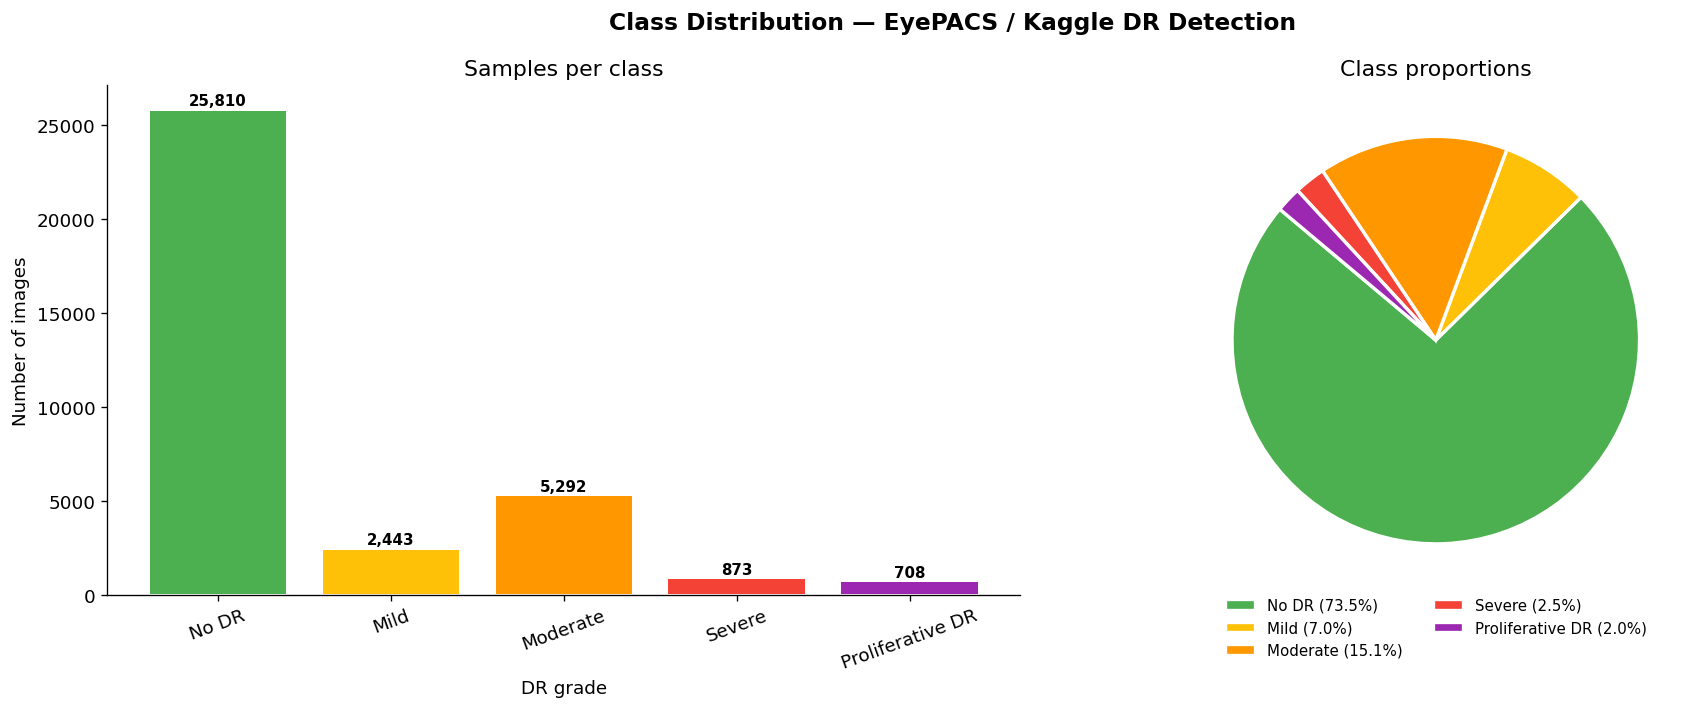

Saved: /content/drive/MyDrive/GSN - studia podyplomowe/gsn-federated/eda_output/class_distribution.pdf


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Class Distribution — EyePACS / Kaggle DR Detection', fontsize=14, fontweight='bold')

# Bar chart
bars = axes[0].bar(
    [CLASS_NAMES[i] for i in counts.index], counts.values,
    color=CLASS_COLORS, edgecolor='white', linewidth=1.2
)
for bar, cnt in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
                 f'{cnt:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_ylabel('Number of images')
axes[0].set_xlabel('DR grade')
axes[0].set_title('Samples per class')
axes[0].tick_params(axis='x', rotation=20)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

wedges, _ = axes[1].pie(
    counts.values,
    colors=CLASS_COLORS, startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].legend(
    wedges,
    [f'{CLASS_NAMES[i]} ({v/total*100:.1f}%)' for i, v in zip(counts.index, counts.values)],
    loc='lower center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=2,
    fontsize=9,
    frameon=False
)
axes[1].set_title('Class proportions')

plt.tight_layout()
out = EDA_DIR / 'class_distribution.pdf'
plt.savefig(out, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

In [7]:
print('=== Class Imbalance Implications for Federated Learning ===')
print()

majority_pct = counts[0] / total * 100
minority_pct = counts[counts.index[-1]] / total * 100
ratio        = counts.max() / counts.min()

print(f'  Dominant class (No DR) : {majority_pct:.1f}% of all samples')
print(f'  Rarest class           : {minority_pct:.1f}%')
print(f'  Imbalance ratio        : {ratio:.0f}x')
print()

for n_clients in [3, 5, 10]:
    print(f'  IID split across {n_clients} clients:')
    for cls, cnt in counts.items():
        per_client = cnt // n_clients
        flag = '⚠️ ' if per_client < 100 else '   '
        print(f'  {flag} Class {cls} ({CLASS_NAMES[cls]:<20}): ~{per_client:>5} samples/client')
    print()

=== Class Imbalance Implications for Federated Learning ===

  Dominant class (No DR) : 73.5% of all samples
  Rarest class           : 2.0%
  Imbalance ratio        : 36x

  IID split across 3 clients:
      Class 0 (No DR               ): ~ 8603 samples/client
      Class 1 (Mild                ): ~  814 samples/client
      Class 2 (Moderate            ): ~ 1764 samples/client
      Class 3 (Severe              ): ~  291 samples/client
      Class 4 (Proliferative DR    ): ~  236 samples/client

  IID split across 5 clients:
      Class 0 (No DR               ): ~ 5162 samples/client
      Class 1 (Mild                ): ~  488 samples/client
      Class 2 (Moderate            ): ~ 1058 samples/client
      Class 3 (Severe              ): ~  174 samples/client
      Class 4 (Proliferative DR    ): ~  141 samples/client

  IID split across 10 clients:
      Class 0 (No DR               ): ~ 2581 samples/client
      Class 1 (Mild                ): ~  244 samples/client
      Class 2 

Images available locally: 10 / 35,126

Analyzed 10 images:
  Width  : min=2592, max=4928, avg=4010, median=3888
  Height : min=1944, max=3264, avg=2712, median=2592
  Modes  : [('RGB', 10)]
  Unique sizes: 4


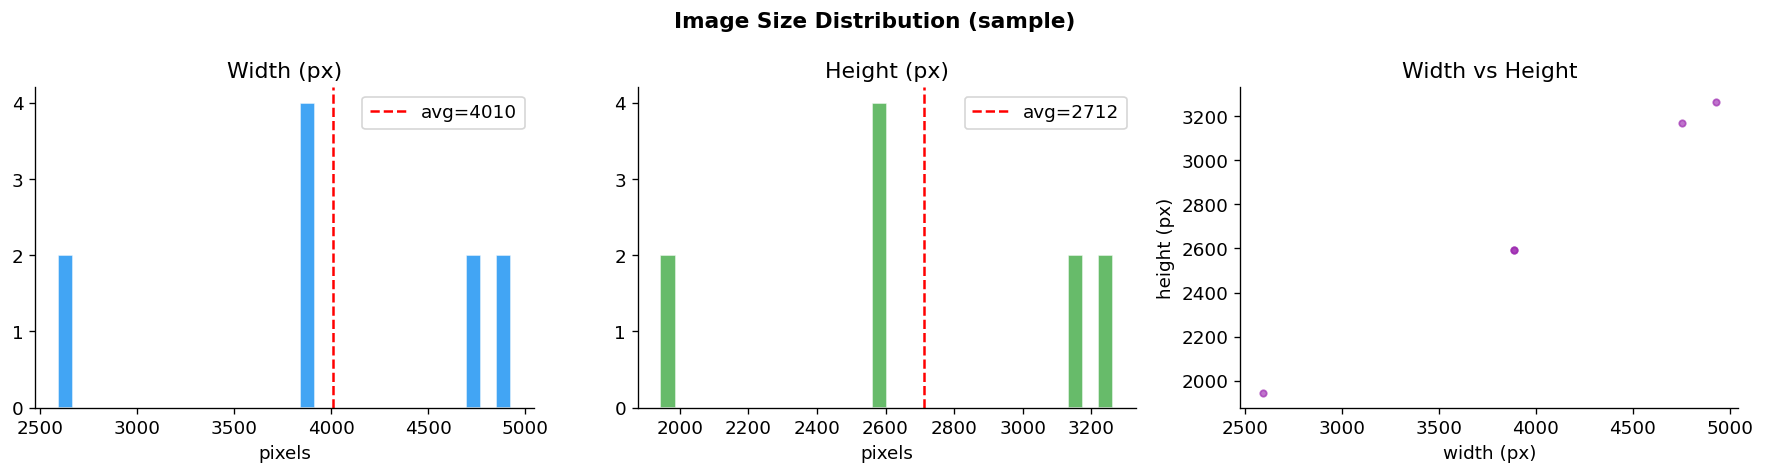

Saved: /content/drive/MyDrive/GSN - studia podyplomowe/gsn-federated/eda_output/image_sizes.pdf

Preprocessing note:
   Images vary widely in resolution — resizing is required.
   Recommended: 224×224 (EfficientNet-B0) or 512×512 (better quality, slower training).
   Use transforms.Resize + CenterCrop or resize with aspect ratio preservation + padding.


In [8]:
def find_image(name: str) -> Path | None:
    for ext in ['', '.jpeg', '.jpg', '.png']:
        p = TRAIN_DIR / f'{name}{ext}'
        if p.exists():
            return p
    return None

available = [row['image'] for _, row in df.iterrows() if find_image(row['image']) is not None]
print(f'Images available locally: {len(available):,} / {len(df):,}')

if len(available) == 0:
    print()
    print('   No local images found (only trainLabels.csv was downloaded).')
    print('   Image size analysis and sample grid will be unavailable.')
    print('   Download sample.zip from the Kaggle competition page to enable these sections.')
    IMAGES_AVAILABLE = False
else:
    IMAGES_AVAILABLE = True
    sample_names = available[:min(300, len(available))]
    widths, heights, modes = [], [], []

    for name in sample_names:
        p = find_image(name)
        try:
            with Image.open(p) as img:
                w, h = img.size
                widths.append(w)
                heights.append(h)
                modes.append(img.mode)
        except Exception:
            pass

    print(f'\nAnalyzed {len(widths)} images:')
    print(f'  Width  : min={min(widths)}, max={max(widths)}, avg={np.mean(widths):.0f}, median={np.median(widths):.0f}')
    print(f'  Height : min={min(heights)}, max={max(heights)}, avg={np.mean(heights):.0f}, median={np.median(heights):.0f}')
    print(f'  Modes  : {Counter(modes).most_common()}')
    print(f'  Unique sizes: {len(set(zip(widths, heights)))}')

if IMAGES_AVAILABLE and widths:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle('Image Size Distribution (sample)', fontsize=13, fontweight='bold')

    axes[0].hist(widths, bins=30, color='#2196F3', alpha=0.85, edgecolor='white')
    axes[0].axvline(np.mean(widths), color='red', linestyle='--', label=f'avg={np.mean(widths):.0f}')
    axes[0].set_title('Width (px)')
    axes[0].set_xlabel('pixels')
    axes[0].legend()

    axes[1].hist(heights, bins=30, color='#4CAF50', alpha=0.85, edgecolor='white')
    axes[1].axvline(np.mean(heights), color='red', linestyle='--', label=f'avg={np.mean(heights):.0f}')
    axes[1].set_title('Height (px)')
    axes[1].set_xlabel('pixels')
    axes[1].legend()

    axes[2].scatter(widths, heights, alpha=0.4, s=15, color='#9C27B0')
    axes[2].set_title('Width vs Height')
    axes[2].set_xlabel('width (px)')
    axes[2].set_ylabel('height (px)')

    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.tight_layout()
    out = EDA_DIR / 'image_sizes.pdf'
    plt.savefig(out, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out}')
    print('\nPreprocessing note:')
    print('   Images vary widely in resolution — resizing is required.')
    print('   Recommended: 224×224 (EfficientNet-B0) or 512×512 (better quality, slower training).')
    print('   Use transforms.Resize + CenterCrop or resize with aspect ratio preservation + padding.')

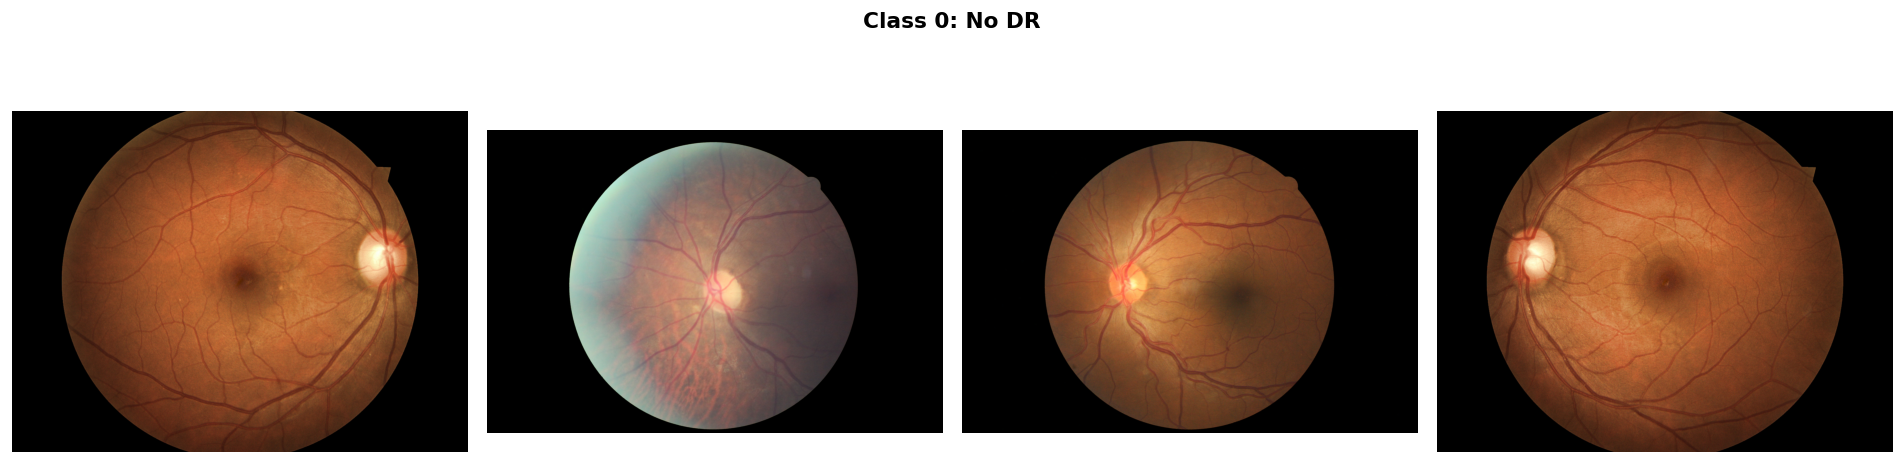

Saved: /content/drive/MyDrive/GSN - studia podyplomowe/gsn-federated/eda_output/samples_class_0.pdf


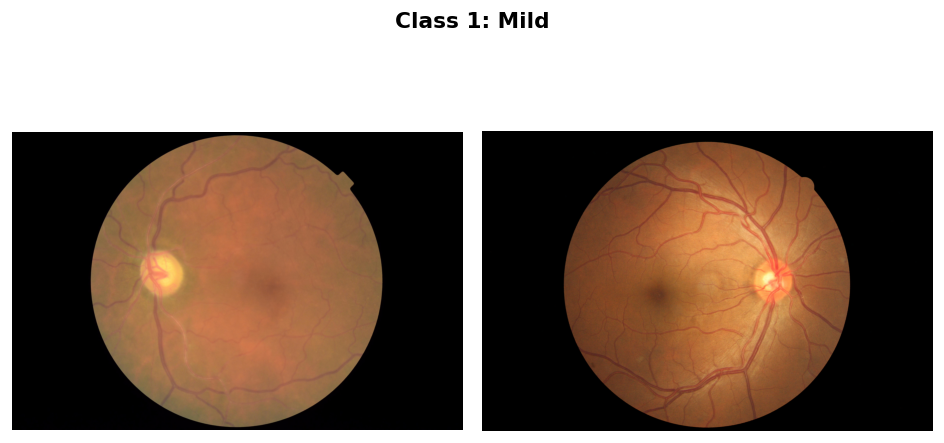

Saved: /content/drive/MyDrive/GSN - studia podyplomowe/gsn-federated/eda_output/samples_class_1.pdf


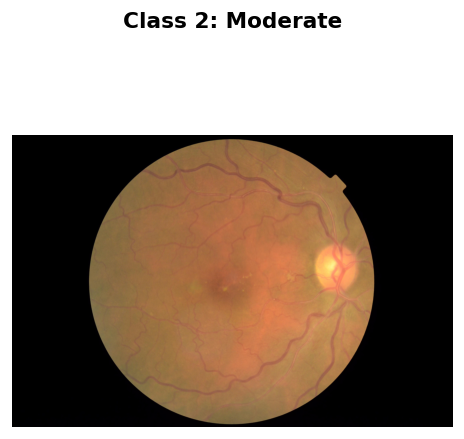

Saved: /content/drive/MyDrive/GSN - studia podyplomowe/gsn-federated/eda_output/samples_class_2.pdf
Class 3: no images found


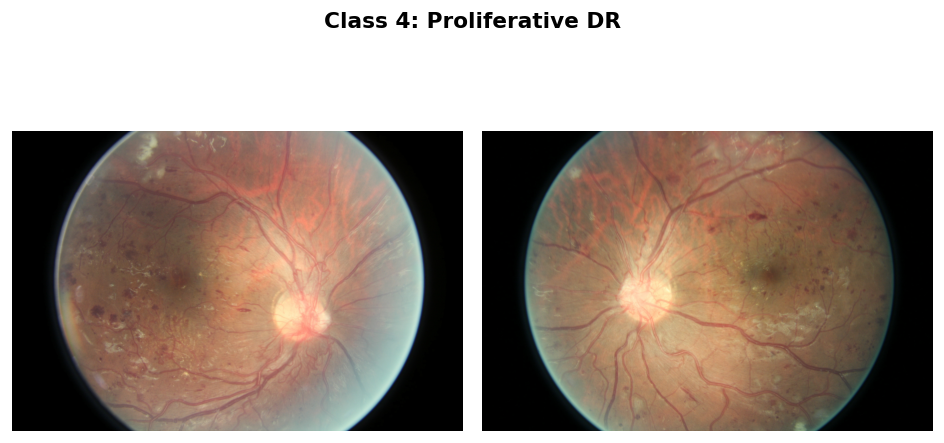

Saved: /content/drive/MyDrive/GSN - studia podyplomowe/gsn-federated/eda_output/samples_class_4.pdf


In [9]:
for cls in range(5):
    class_rows = df[df['level'] == cls].sample(frac=1, random_state=42)

    images = []
    for _, row in class_rows.iterrows():
        if len(images) >= 4:
            break
        p = find_image(row['image'])
        if p is None:
            continue
        try:
            images.append(Image.open(p).convert('RGB'))
        except Exception:
            pass

    if not images:
        print(f'Class {cls}: no images found')
        continue

    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=(n * 4, 4))
    if n == 1:
        axes = [axes]

    fig.suptitle(f'Class {cls}: {CLASS_NAMES[cls]}',
                 fontsize=13, fontweight='bold',
                 y=1.02)

    for ax, img in zip(axes, images):
        ax.imshow(img)
        ax.axis('off')

    plt.tight_layout()
    out = EDA_DIR / f'samples_class_{cls}.pdf'
    plt.savefig(out, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out}')

In [10]:
if not IMAGES_AVAILABLE:
    print('No images available.')
else:
    SAMPLE_PER_CLASS = min(20, len(available) // 5)
    means_r, means_g, means_b = [], [], []
    class_labels_sample = []

    for cls in range(5):
        rows = df[df['level'] == cls]
        rows = rows[rows['image'].isin(available)]
        if len(rows) == 0:
            continue
        rows = rows.sample(min(SAMPLE_PER_CLASS, len(rows)), random_state=cls)
        for _, row in rows.iterrows():
            p = find_image(row['image'])
            if p is None:
                continue
            try:
                img = np.array(Image.open(p).convert('RGB').resize((128, 128)))
                means_r.append(img[:, :, 0].mean())
                means_g.append(img[:, :, 1].mean())
                means_b.append(img[:, :, 2].mean())
                class_labels_sample.append(cls)
            except Exception:
                pass

    print('Mean RGB channel values per class:')
    for cls in range(5):
        idxs = [i for i, c in enumerate(class_labels_sample) if c == cls]
        if not idxs:
            continue
        r = np.mean([means_r[i] for i in idxs])
        g = np.mean([means_g[i] for i in idxs])
        b = np.mean([means_b[i] for i in idxs])
        print(f'  Class {cls} ({CLASS_NAMES[cls]:<20}): R={r:.1f}, G={g:.1f}, B={b:.1f}')

    print(f'\n  Overall: R={np.mean(means_r):.1f}, G={np.mean(means_g):.1f}, B={np.mean(means_b):.1f}')
    print(f'\n  ImageNet normalization (mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])')
    print('  is standard for EfficientNet and ImageNet-pretrained models.')
    print('  Alternative: compute mean/std directly from the training set.')

Mean RGB channel values per class:
  Class 0 (No DR               ): R=76.4, G=51.4, B=37.8
  Class 1 (Mild                ): R=78.8, G=50.2, B=30.6
  Class 2 (Moderate            ): R=84.9, G=58.2, B=36.0
  Class 4 (Proliferative DR    ): R=110.4, G=87.6, B=72.0

  Overall: R=88.0, G=62.4, B=45.3

  ImageNet normalization (mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
  is standard for EfficientNet and ImageNet-pretrained models.
  Alternative: compute mean/std directly from the training set.


## Summary

### Dataset
- **35,126** training images (left + right eye per patient)
- **5 classes**: 0 = No DR → 4 = Proliferative DR
- Format: JPEG, varying resolutions (~500px to ~4000px)

### Class Distribution
| Class | Name | Count | % |
|-------|------|------:|--:|
| 0 | No DR | 25,810 | 73.5% |
| 1 | Mild | 2,443 | 7.0% |
| 2 | Moderate | 5,292 | 15.1% |
| 3 | Severe | 873 | 2.5% |
| 4 | Proliferative DR | 708 | 2.0% |

**Imbalance ratio: 36x** (No DR vs Proliferative DR)

### Preprocessing Recommendations
- Resize to **224×224** (EfficientNet-B0 input)
- Augmentation: `RandomHorizontalFlip`, `RandomRotation(15°)`, `ColorJitter`
- Normalization: ImageNet stats `mean=[0.485, 0.456, 0.406]`, `std=[0.229, 0.224, 0.225]`
  - Note: fundus images are darker and more red-shifted than natural photos (overall mean RGB: [88, 62, 45]), but ImageNet normalization remains standard for pretrained models

### Federated Learning Implications
- **Number of clients: 5** — ensures all classes have >100 samples/client under IID split; 10 clients would leave classes 3 and 4 with <100 samples/client
- **Partitioning: Dirichlet α=0.5** — non-IID split simulating realistic data heterogeneity across clinics
- **Loss function: weighted CrossEntropyLoss** — weights inversely proportional to class frequency
- **Metric: Quadratic Weighted Kappa (QWK)** — accuracy is misleading (predicting class 0 always gives 73.5%)
- Class 4 (Proliferative DR) shows higher brightness (R=110 vs overall R=88), likely due to neovascularization and laser photocoagulation scars — model must learn subtle texture differences, not just brightness